## 1. Import dependencies

In [1]:
from pathlib import Path
import random
import warnings

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from skimage.feature import hog
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)
from sklearn.model_selection import ParameterGrid
import joblib

warnings.filterwarnings("ignore")

## 2. Configure random seed and data path

In [ ]:
SEED = 38
random.seed(SEED)
np.random.seed(SEED)

# dataset directory
DATASET_DIR = Path("./chest_xray")

# image format 
IMG_EXTENSIONS = {".jpeg", ".jpg"}

# output directories
OUTPUT_DIR = Path("./outputs")
MODEL_DIR = Path("./models")
OUTPUT_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

# image resizing (as preprocessing before HOG)
IMAGE_SIZE = (128, 128)

# labels mapping: NORMAL=0, PNEUMONIA=1
CLASS_TO_IDX = {
    "NORMAL": 0,
    "PNEUMONIA": 1
}
IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}

print("DATASET_DIR =", DATASET_DIR.resolve())

DATASET_DIR = /Users/wangzhichong/ML_HW/project/main/chest_xray


## 3. Count the number of images in each subfolder

In [3]:
def list_images_in_dir(folder: Path):
    return sorted([
        p for p in folder.iterdir()
        if p.is_file() and p.suffix.lower() in IMG_EXTENSIONS
    ])

def count_images(dataset_dir: Path):
    stats = {}
    for split in ["train", "val", "test"]:
        stats[split] = {}
        for cls in ["NORMAL", "PNEUMONIA"]:
            cls_dir = dataset_dir / split / cls
            stats[split][cls] = len(list_images_in_dir(cls_dir))
    return stats

stats = count_images(DATASET_DIR)
stats

{'train': {'NORMAL': 1140, 'PNEUMONIA': 3294},
 'val': {'NORMAL': 209, 'PNEUMONIA': 589},
 'test': {'NORMAL': 234, 'PNEUMONIA': 390}}

## 4. Visualized sample images

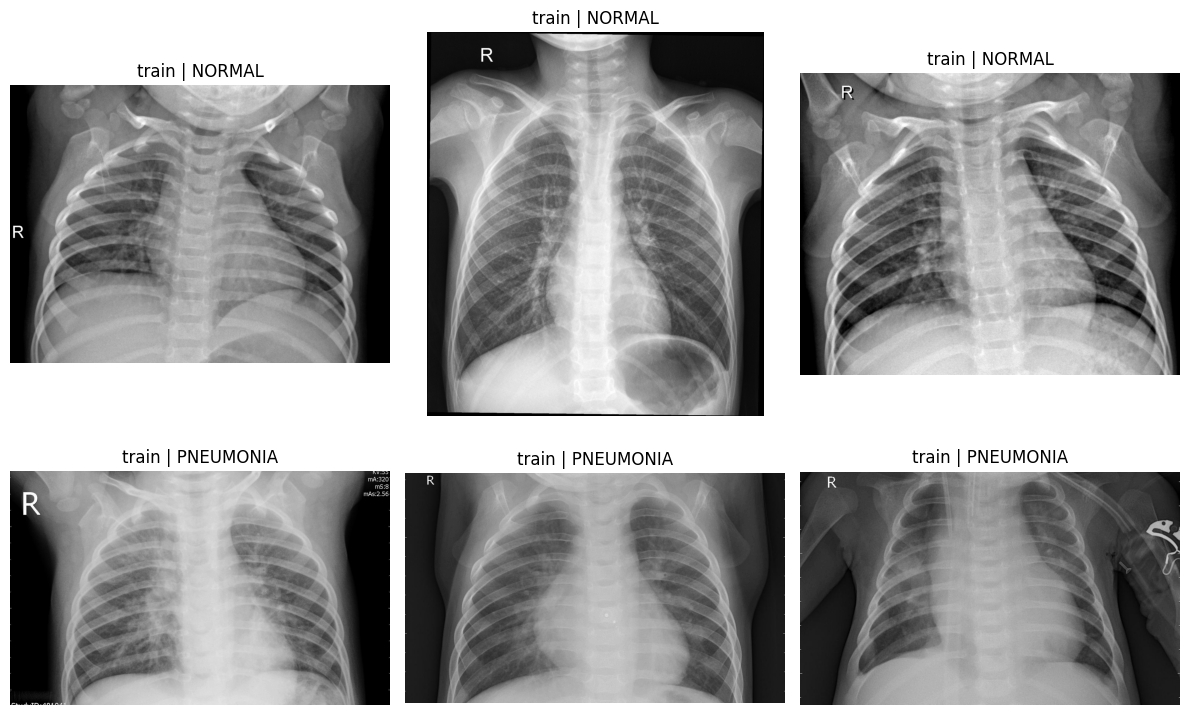

In [4]:
def show_random_samples(dataset_dir: Path, split="train", n_per_class=3):
    fig, axes = plt.subplots(2, n_per_class, figsize=(4 * n_per_class, 8))
    classes = ["NORMAL", "PNEUMONIA"]

    for row, cls in enumerate(classes):
        img_paths = list_images_in_dir(dataset_dir / split / cls)
        chosen = random.sample(img_paths, min(n_per_class, len(img_paths)))

        for col in range(n_per_class):
            ax = axes[row, col]
            ax.axis("off")

            if col < len(chosen):
                img = Image.open(chosen[col]).convert("L")
                ax.imshow(img, cmap="gray")
                ax.set_title(f"{split} | {cls}")

    plt.tight_layout()
    plt.show()

show_random_samples(DATASET_DIR, split="train", n_per_class=3)

## 5. Define image preprocessing and HOG feature extraction functions

In [ ]:
# extract hog feature of images
def load_grayscale_image(img_path: Path, image_size=(128, 128)):
    img = Image.open(img_path).convert("L")
    img = img.resize(image_size) #resize to (128, 128)
    img = np.array(img, dtype=np.float32) / 255.0 #normalized to [0,1]
    return img

def extract_hog_feature(image: np.ndarray):
    feature = hog(
        image,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        transform_sqrt=True,
        feature_vector=True
    )
    return feature

## 6. Transform the entire dataset into a feature matrix

In [ ]:
def build_features_and_labels(dataset_dir: Path, split: str, image_size=(128, 128)):
    X, y, paths = [], [], []

    for cls_name, label in CLASS_TO_IDX.items():
        cls_dir = dataset_dir / split / cls_name
        img_paths = list_images_in_dir(cls_dir)

        for img_path in img_paths:
            img = load_grayscale_image(img_path, image_size=image_size) # load
            feat = extract_hog_feature(img) # extract features

            X.append(feat) # feature
            y.append(label) # label
            paths.append(str(img_path))

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int64)
    return X, y, paths

print("Begin extracting the features of train set...")
X_train, y_train, train_paths = build_features_and_labels(DATASET_DIR, "train", IMAGE_SIZE)

print("Begin extracting the features of val set...")
X_val, y_val, val_paths = build_features_and_labels(DATASET_DIR, "val", IMAGE_SIZE)

print("Begin extracting the features of test set...")
X_test, y_test, test_paths = build_features_and_labels(DATASET_DIR, "test", IMAGE_SIZE)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape, "y_val  :", y_val.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)

Begin extracting the features of train set...
Begin extracting the features of val set...
Begin extracting the features of test set...
X_train: (4434, 8100) y_train: (4434,)
X_val  : (798, 8100) y_val  : (798,)
X_test : (624, 8100) y_test : (624,)


## 7. Build an SVM classifier and perform parameter tuning

In [ ]:
# SVM parameter search
param_grid = {
    "svm__C": [0.001, 0.005, 0.01, 0.1, 1.0,]
}

best_model = None
best_params = None
best_val_acc = -1.0
results = []

for params in ParameterGrid(param_grid):
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", LinearSVC(
            C=params["svm__C"],
            random_state=SEED,
            max_iter=10000,
            class_weight="balanced" #since the class is not balanced
        ))
    ])

    model.fit(X_train, y_train) #fit
    val_pred = model.predict(X_val)
    val_acc = accuracy_score(y_val, val_pred)

    results.append((params["svm__C"], val_acc))
    print(f"C = {params['svm__C']:<5} | Val Accuracy = {val_acc:.4f}")

    if val_acc > best_val_acc: # choose model according to val acc
        best_val_acc = val_acc
        best_params = params
        best_model = model

print("\nBest parameter:", best_params)
print("Best accuracy of val set:", round(best_val_acc, 4))

C = 0.001 | Val Accuracy = 0.9524
C = 0.005 | Val Accuracy = 0.9524
C = 0.01  | Val Accuracy = 0.9524
C = 0.1   | Val Accuracy = 0.9474
C = 1.0   | Val Accuracy = 0.9474

Best parameter: {'svm__C': 0.001}
Best accuracy of val set: 0.9524


## 8. Evaluate the best model on the test set

> - Accuracy
> - Classification Report
> - Confusion Matrix
> - ROC-AUC
> - ROC Curve

In [ ]:
# test on test set
test_pred = best_model.predict(X_test)
test_scores = best_model.decision_function(X_test) #get scores for computing ROC-AUC

test_acc = accuracy_score(y_test, test_pred)
test_roc_auc = roc_auc_score(y_test, test_scores)

print("Test Accuracy:", round(test_acc, 4))
print("Test ROC-AUC:", round(test_roc_auc, 4))

Test Accuracy: 0.7885
Test ROC-AUC: 0.875


In [9]:
print("Classification Report: (SVM)")
print(classification_report(
    y_test,
    test_pred,
    target_names=["NORMAL", "PNEUMONIA"],
    digits=4
))

Classification Report: (SVM)
              precision    recall  f1-score   support

      NORMAL     0.8643    0.5171    0.6471       234
   PNEUMONIA     0.7665    0.9513    0.8490       390

    accuracy                         0.7885       624
   macro avg     0.8154    0.7342    0.7480       624
weighted avg     0.8032    0.7885    0.7733       624



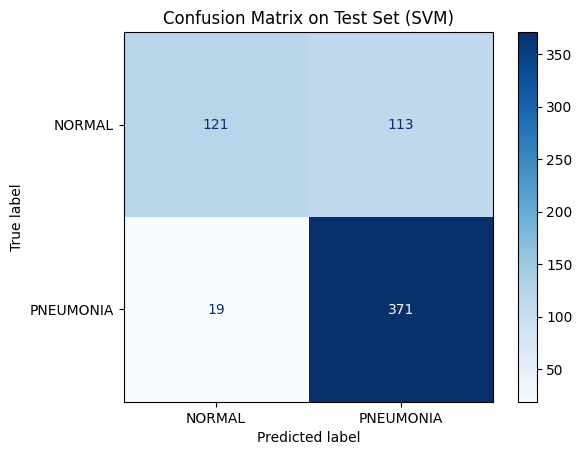

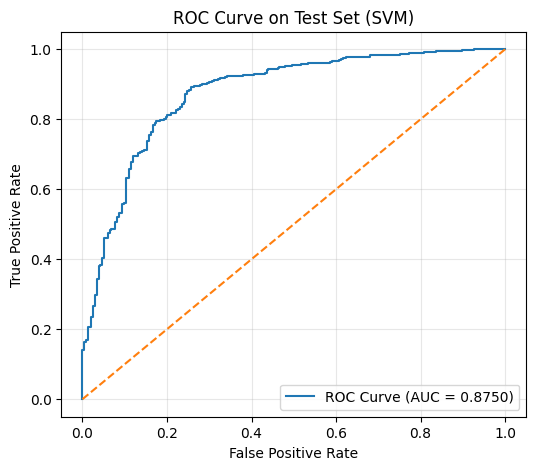

In [ ]:
# plot confusion matrix
cm = confusion_matrix(y_test, test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["NORMAL", "PNEUMONIA"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix on Test Set (SVM)")
plt.savefig(OUTPUT_DIR / "SVM_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, test_scores)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {test_roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve on Test Set (SVM)")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(OUTPUT_DIR / "SVM_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

## 9. Observe the samples with incorrect predictions

Number of misclassified Samples: 132


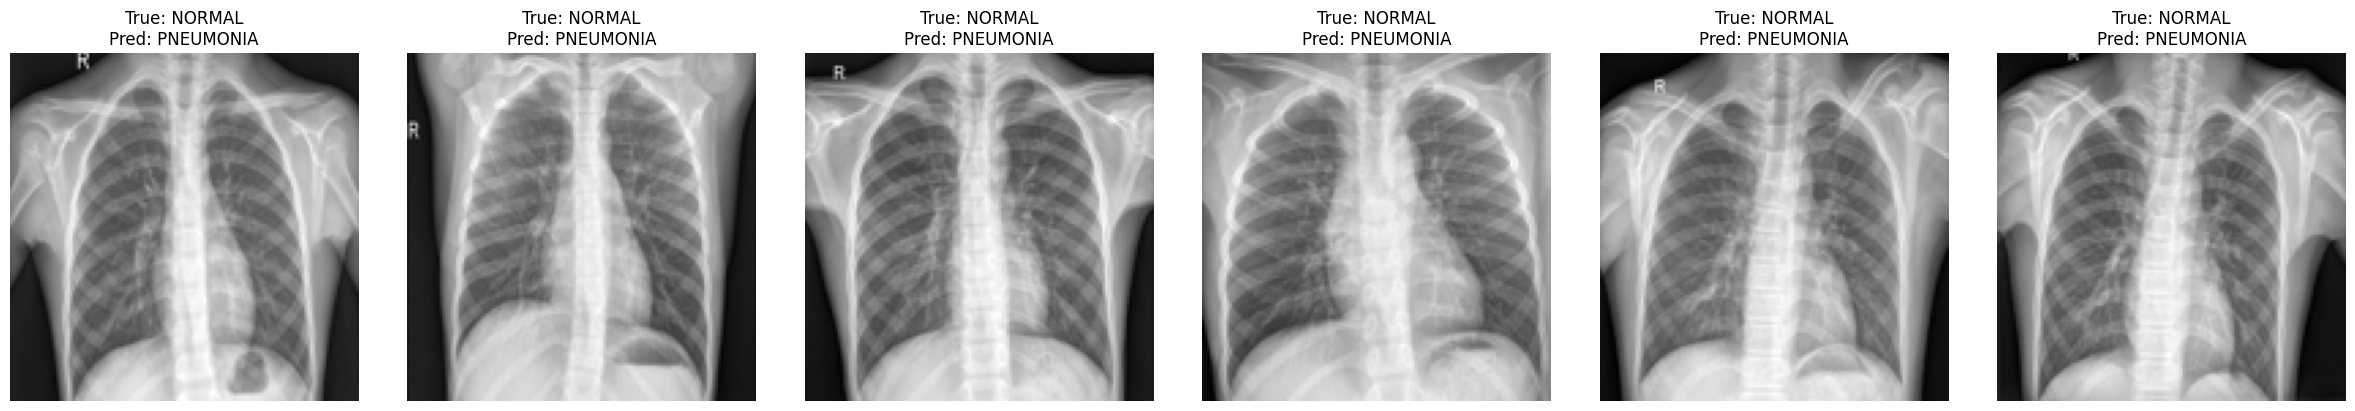

In [11]:
def show_misclassified_samples(X, y_true, y_pred, paths, n=6, image_size=(128, 128)):
    mis_idx = np.where(y_true != y_pred)[0]
    print(f"Number of misclassified Samples: {len(mis_idx)}")

    if len(mis_idx) == 0:
        print("No misclassified samples.")
        return

    chosen = mis_idx[:min(n, len(mis_idx))]
    fig, axes = plt.subplots(1, len(chosen), figsize=(4 * len(chosen), 4))
    if len(chosen) == 1:
        axes = [axes]

    for ax, idx in zip(axes, chosen):
        img = load_grayscale_image(Path(paths[idx]), image_size=image_size)
        ax.imshow(img, cmap="gray")
        ax.set_title(f"True: {IDX_TO_CLASS[y_true[idx]]}\nPred: {IDX_TO_CLASS[y_pred[idx]]}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_misclassified_samples(X_test, y_test, test_pred, test_paths, n=6, image_size=IMAGE_SIZE)

## 10. Save the best model

> The model save to `models/`  
> Images results save to `outputs/`

In [12]:
model_path = MODEL_DIR / "hog_svm_pipeline.joblib"
joblib.dump(best_model, model_path)

print("Best model has saved to:", model_path.resolve())

Best model has saved to: /Users/wangzhichong/ML_HW/project/main/models/hog_svm_pipeline.joblib
